In [1]:
from dotenv import load_dotenv
load_dotenv()

from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing import Annotated, Literal

In [ ]:
# schema for sturctured output
class FlowState(BaseModel):
    question: str = Field(description="user asked question")
    category: Literal['coding', 'google_search', 'weather'] = Field(default="google_search")  # coding, google_search, weather
    answer: str = Field(default="")

In [ ]:
# schema for sturctured output
class QuestionCategoryState(BaseModel):
    category: Literal["coding", "google_search", "weather"] = Field(
        default="google_search",
        description="One of: coding (programming/code), weather (forecast/temp), google_search (general/factual lookup).",
    )


In [4]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
)

### Nodes

In [ ]:
def question_category(state: FlowState) -> FlowState:
    sto_llm = llm.with_structured_output(QuestionCategoryState, method="json_mode")
    res = sto_llm.invoke(
        f"""Classify the user question into exactly one category.

            Question: {state.question}

            Return ONLY valid JSON matching this schema:
            {{"category": "coding" | "google_search" | "weather"}}

            Rules:
            - coding: programming, algorithms, debugging, writing code
            - weather: weather, temperature, forecast
            - google_search: general/factual questions, or when unsure (default)
        """
    )
    print(res)
    state.category = res.category

    return state


In [6]:
query = FlowState(question="two sum problem in c++")
question_category(query)

category='coding'


FlowState(question='two sum problem in c++', category='coding', answer='')

In [7]:
# routing node (based on category):
def node_routing(state: FlowState)->Literal['coding', 'google_search', 'weather']:
    return state.category

In [8]:
#nodes:
from langchain.agents import create_agent
from langchain_community.utilities.google_serper import GoogleSerperAPIWrapper
from langchain_core.tools import tool
import re

search = GoogleSerperAPIWrapper()


# google search node:
@tool
def search_tool(query: str) -> str:
    """Search Google with a simple query (no quotes or OR operators)."""
    # Serper free accounts reject advanced operators like quotes / OR
    simple = re.sub(r'[\"\']', "", query)
    simple = re.sub(r"\bOR\b", " ", simple, flags=re.IGNORECASE)
    simple = re.sub(r"\s+", " ", simple).strip()
    return search.run(simple)


search_agent = create_agent(
    model=llm,
    tools=[search_tool],
    system_prompt="""
                    You are a research assistant.

                    Use Google Search whenever the question requires current
                    or factual information.

                    When calling search_tool, use a SHORT plain-text query
                    with no quotes and no OR/AND operators.

                    Answer the user's question based on the search results.
                    If something cannot be verified, clearly say so.

                    Give a concise, short, direct answer.
                    """
)
    
def google_search_node(state: FlowState)->FlowState:
    res = search_agent.invoke({"messages":[
        {
            "role":"user",
            "content":state.question
        }
    ]})
    state.answer = res["messages"][-1].content
    
    return state;


# coding node:
def coding_node(state: FlowState)->FlowState:
    res = llm.invoke(f""" You are a coding expert and the question is {state.question} """)
    state.answer = res.content
    
    return state;


# weather node:
def weather_node(state: FlowState)->FlowState:
    res = llm.invoke(f""" You are a weather expert and the question is {state.question} """)
    state.answer = "weather is cool, 5 deg."
    
    return state;


C:\Users\sarka\AppData\Local\Temp\ipykernel_24992\917639456.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities.google_serper import GoogleSerperAPIWrapper


In [9]:
graph = StateGraph(FlowState)

graph.add_node("question_category", question_category)
graph.add_node("coding", coding_node)
graph.add_node("google_search", google_search_node)
graph.add_node("weather", weather_node)

In [10]:
# edges:
graph.add_edge(START,"question_category")
graph.add_conditional_edges("question_category", node_routing)
graph.add_edge("coding", END)
graph.add_edge("google_search", END)
graph.add_edge("weather", END)

graph = graph.compile()

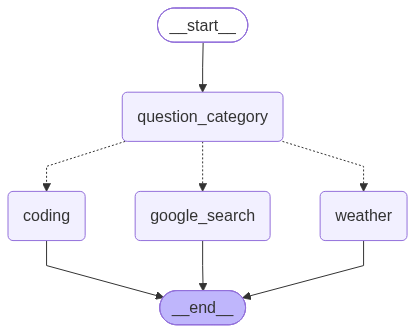

In [11]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [17]:
response = graph.invoke({
    "question": "longest subarray without repeating character?"
})

print(response["answer"])

category='coding'
## Longest Sub‑Array (or Sub‑String) with All Distinct Elements

The classic “longest substring without repeating characters” problem is the same as
finding the longest contiguous sub‑array of an array (or a string) that contains
no duplicate values.

```
Input :  [1, 2, 3, 2, 4, 5, 3, 6]
Output:  4   (sub‑array [2, 4, 5, 3] or [4,5,3,6])
```

Below is a complete, language‑agnostic description of the optimal solution,
followed by ready‑to‑run code snippets in **Python**, **JavaScript**, and **Java**.

---

## 1.  Core Idea – Sliding Window + Hash Map / Set

* **Sliding window** keeps track of the current sub‑array that contains only
  distinct elements.
* A **hash map / set** stores the last seen index (or existence) of each
  element inside the current window.
* While iterating through the array:
  * If the current element is *not* in the window → extend the window.
  * If the current element *is* already inside the window → shrink the window
    from the left until 